# ISAS Challenge: TSFEL + HistGradientBoosting

Pipeline order: validate data, engineer pose signals, extract TSFEL features, run four independent LOSO folds for S1/S2/S3/S5, fit the final model on all four labeled subjects, and predict S4.

In [1]:
from pathlib import Path
import inspect, json, os, sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix
import sklearn, tsfel
from tsfel_histgb_pipeline import *
from train_tsfel_histgb import load_or_extract_subject

DATA_DIR = Path(os.environ.get('KEYPOINT_DATA_DIR', 'data/keypointlabel'))
TEST_FILE = Path(os.environ.get('KEYPOINT_TEST_FILE', 'data/test_data_keypoint_shared.csv'))
S4_LABEL_FILE = Path(os.environ.get('KEYPOINT_S4_LABEL_FILE', 'data/keypointlabel/keypoints_with_labels_4.csv'))
SUBJECTS = [1, 2, 3, 5]
PARTICIPANT_ID = 4
ARTIFACT_DIR = Path('artifacts/tsfel_histgb')
CACHE_DIR = ARTIFACT_DIR / 'cache'
OUTPUT_DIR = Path('outputs/tsfel_histgb')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Python:', sys.executable)
print('TSFEL:', getattr(tsfel, '__version__', '0.2.0'), '| sklearn:', sklearn.__version__)

Python: python
TSFEL: 0.2.0 | sklearn: 1.7.2


## 1. Schema and Label Validation

In [2]:
training_files = {s: DATA_DIR / f'keypoints_with_labels_{s}.csv' for s in SUBJECTS}
schema_rows = []
for subject, path in training_files.items():
    header = pd.read_csv(path, nrows=2)
    validate_pose_columns(header)
    assert 'Action Label' in header.columns
    schema_rows.append({'subject': subject, 'file': path.name, 'columns': len(header.columns)})
test_header = pd.read_csv(TEST_FILE, nrows=2)
validate_pose_columns(test_header)
display(pd.DataFrame(schema_rows))
print('Test columns:', len(test_header.columns), '| labeled:', 'Action Label' in test_header.columns)

,subject,file,columns
0,1,keypoints_with_labels_1.csv,36
1,2,keypoints_with_labels_2.csv,36
2,3,keypoints_with_labels_3.csv,36
3,5,keypoints_with_labels_5.csv,36


Test columns: 35 | labeled: False


## 2. V7-Compatible Pose Feature Engineering Before TSFEL

This stage preserves the behavior-oriented feature engineering from v7 while making it valid for LOSO. Full-subject aggregate values are replaced by frame-level signals that TSFEL summarizes inside each window. The corrected pipeline does not depend on `custom_features.py` or `tsfel_feat.json`.

- Normalization: center on the hip midpoint and scale by shoulder width, with a torso-length fallback.
- Geometry: shoulder, hip, knee, ankle, hand-to-head, hand-to-hip, and hand-to-floor distances.
- Posture: elbow, knee, hip, torso, and shoulder-tilt angles plus posture masks.
- Motion: head, wrist, ankle, knee, and center-of-mass velocity, acceleration, and jerk.
- Behavior interactions: hand-near-head, hand-to-mouth motion, low motion, static wrists, grounded wrists, and wrist-to-COM jerk ratio.

In [3]:
# This is the feature-engineering function applied to each subject before TSFEL.
print(inspect.getsource(add_pose_signals))

def add_pose_signals(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    distance_pairs = {
        "dist_shoulders": ("left_shoulder", "right_shoulder"),
        "dist_hips": ("left_hip", "right_hip"),
        "dist_knees": ("left_knee", "right_knee"),
        "dist_ankles": ("left_ankle", "right_ankle"),
        "dist_wrist_to_hip": ("right_wrist", "right_hip"),
        "dist_lw_nose": ("left_wrist", "nose"),
        "dist_rw_nose": ("right_wrist", "nose"),
        "dist_lw_ear": ("left_wrist", "left_ear"),
        "dist_rw_ear": ("right_wrist", "right_ear"),
        "dist_la_lhip": ("left_ankle", "left_hip"),
        "dist_ra_rhip": ("right_ankle", "right_hip"),
    }
    for name, (point_a, point_b) in distance_pairs.items():
        out[name] = _distance_xy(
            out[f"{point_a}_x"], out[f"{point_a}_y"], out[f"{point_b}_x"], out[f"{point_b}_y"]
        )

    angle_definitions = {
        "angle_elbow_l": ("left_shoulder", "left_elbow", "left_wrist"

In [4]:
preview_raw = pd.read_csv(training_files[1], nrows=900)
preview_prepared = prepare_pose_frame(preview_raw)
preview_normalized = pose_normalize(preview_prepared)
preview_enriched, signal_columns = add_pose_signals(preview_normalized)

def feature_family(name):
    if name.startswith('dist_'):
        return 'Geometry'
    if name.startswith('angle_') or name in {'knee_flex', 'knee_extend', 'elbow_flex'}:
        return 'Posture'
    if name.startswith(('vel_', 'jerk_', 'accel_', 'delta_')) or name in {'duck_proxy', 'max_frame_jerk_rw'}:
        return 'Motion'
    return 'Behavior interaction'

feature_catalog = pd.DataFrame({
    'signal': signal_columns,
    'family': [feature_family(name) for name in signal_columns],
})
print('Feature schema:', FEATURE_SCHEMA_VERSION)
display(feature_catalog.groupby('family').size().rename('signal_count').to_frame())
display(feature_catalog)
display(preview_enriched[signal_columns].head())

Feature schema:

 v7-compatible-1


,signal_count
family,
Behavior interaction,18
Geometry,13
Motion,19
Posture,11


,signal,family
0,dist_shoulders,Geometry
1,dist_hips,Geometry
2,dist_knees,Geometry
3,dist_ankles,Geometry
4,dist_wrist_to_hip,Geometry
...,...,...
56,low_motion,Behavior interaction
57,ground_mask_l,Behavior interaction
58,ground_mask_r,Behavior interaction
59,both_on_ground,Behavior interaction


,dist_shoulders,dist_hips,dist_knees,dist_ankles,dist_wrist_to_hip,dist_lw_nose,dist_rw_nose,dist_lw_ear,dist_rw_ear,dist_la_lhip,...,strong_bite,knee_flex,knee_extend,elbow_flex,static_wrist,low_motion,ground_mask_l,ground_mask_r,both_on_ground,ratio_rwjerk_comjerk
0,1.0,1.068182,2.407953,3.977312,1.045698,7.470312,7.027090,7.520557,7.086199,6.209287,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.000000
1,1.0,1.026299,2.394996,4.096547,0.872125,7.369060,6.855926,7.371448,6.868456,6.056084,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,1.0,1.013187,2.402889,4.062416,0.544059,7.205976,6.832784,7.142147,6.735636,5.850043,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.423886
3,1.0,0.975419,2.263355,3.856781,0.325066,6.729285,6.501727,6.650632,6.362083,5.400314,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.897838
4,1.0,0.980960,2.063300,3.627437,0.178543,6.343738,6.108843,6.221779,5.915537,5.017372,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.725189


## 3. Built-In TSFEL Configuration

In [5]:
config = make_tsfel_config()
enabled = {domain: list(features) for domain, features in config.items()}
display(pd.DataFrame([(domain, name) for domain, names in enabled.items() for name in names], columns=['domain', 'feature']))
print('Pose signals:', len(signal_columns))
print('TSFEL functions per signal:', sum(len(v) for v in config.values()))
print('Expected final features:', len(signal_columns) * sum(len(v) for v in config.values()))

,domain,feature
0,statistical,Absolute energy
1,statistical,Interquartile range
2,statistical,Max
3,statistical,Mean
4,statistical,Mean absolute deviation
5,statistical,Median
6,statistical,Median absolute deviation
7,statistical,Min
8,statistical,Peak to peak distance
9,statistical,Root mean square


Pose signals: 61
TSFEL functions per signal: 31
Expected final features: 1891


## 4. Per-Subject Feature Extraction and Versioned Cache

In [6]:
subject_windows = {}
for subject, path in training_files.items():
    subject_windows[subject] = load_or_extract_subject(path, subject, CACHE_DIR, config, force=False)

window_counts = pd.DataFrame({s: w.y.value_counts() for s, w in subject_windows.items()}).fillna(0).astype(int)
display(window_counts)
print('Feature matrix shapes:', {s: w.x.shape for s, w in subject_windows.items()})

Subject 1: loaded 963 cached windows with 1891 features


Subject 2: reading data/keypointlabel\keypoints_with_labels_2.csv


Subject 2: extracting TSFEL from 74,638 frames


Subject 2: cached 945 windows with 1891 features


Subject 3: loaded 1409 cached windows with 1891 features


Subject 5: loaded 945 cached windows with 1891 features


,1,2,3,5
Action Label,,,,
Attacking,58,76,69,59
Biting,73,37,118,74
Eating snacks,195,195,140,188
Head banging,50,52,80,52
Sitting quietly,190,195,365,198
Throwing things,59,52,49,51
Using phone,144,146,321,134
Walking,194,192,267,189


Feature matrix shapes: {1: (963, 1891), 2: (945, 1891), 3: (1409, 1891), 5: (945, 1891)}


## 5. Four Independent LOSO Cells

Each cell trains on the other three subjects and evaluates one held-out subject with a 150-frame stride and no overlap in the evaluation set.

In [7]:
def show_loso_fold(fold):
    metric_row = {
        'held_out_subject': fold.held_out_subject,
        'n_train_windows': fold.n_train_windows,
        'n_test_windows': fold.n_test_windows,
        **fold.metrics,
    }
    display(pd.DataFrame([metric_row]))
    display(fold.classification_report)
    plt.figure(figsize=(10, 8))
    sns.heatmap(fold.confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(f'LOSO confusion matrix - held-out S{fold.held_out_subject}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

### LOSO S1: Held-Out Subject 1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.551867,0.473515,0.582278,0.589744,0.575


,precision,recall,f1-score,support
Attacking,0.625000,0.344828,0.444444,29.000000
Biting,1.000000,0.027778,0.054054,36.000000
Eating snacks,0.419355,0.795918,0.549296,98.000000
Head banging,0.323944,0.920000,0.479167,25.000000
Sitting quietly,0.038462,0.010526,0.016529,95.000000
Throwing things,0.689655,0.666667,0.677966,30.000000
Using phone,0.900000,0.500000,0.642857,72.000000
Walking,0.858407,1.000000,0.923810,97.000000
accuracy,0.551867,0.551867,0.551867,0.551867
macro avg,0.606853,0.533215,0.473515,482.000000


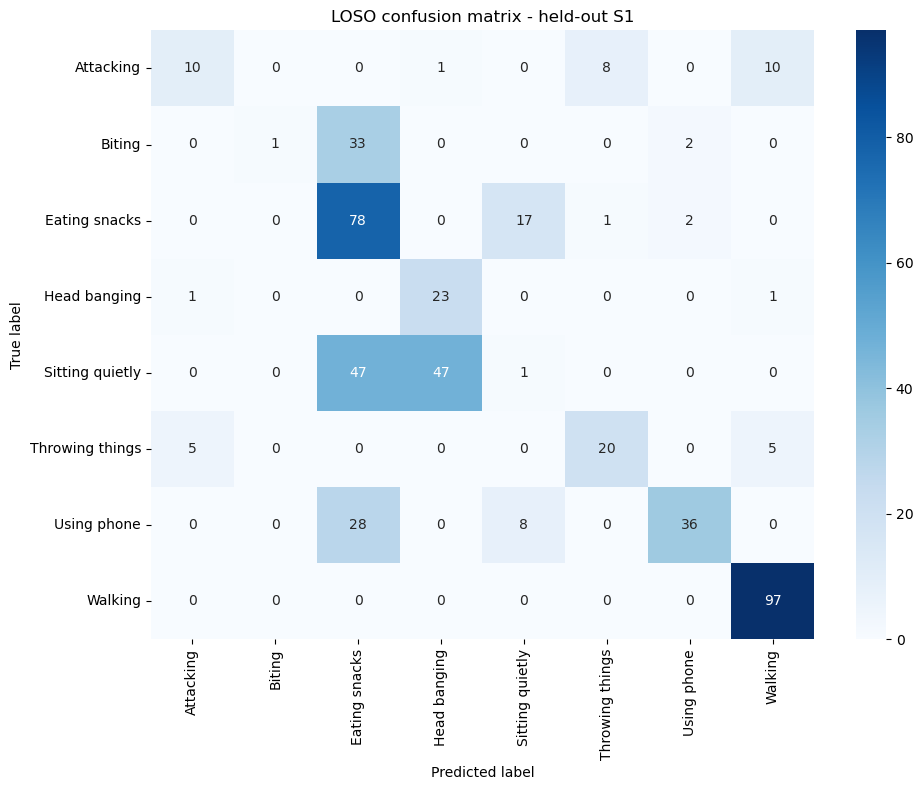

In [8]:
fold_s1 = run_loso_fold(subject_windows, held_out_subject=1, random_state=42)
fold_s1.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_1.csv')
show_loso_fold(fold_s1)

### LOSO S2: Held-Out Subject 2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,3317,472,0.680085,0.597869,0.77512,0.80198,0.75


,precision,recall,f1-score,support
Attacking,0.545455,0.157895,0.244898,38.000000
Biting,0.529412,1.000000,0.692308,18.000000
Eating snacks,0.729167,0.721649,0.725389,97.000000
Head banging,0.742857,1.000000,0.852459,26.000000
Sitting quietly,0.539773,0.969388,0.693431,98.000000
Throwing things,0.666667,0.538462,0.595745,26.000000
Using phone,0.000000,0.000000,0.000000,73.000000
Walking,1.000000,0.958333,0.978723,96.000000
accuracy,0.680085,0.680085,0.680085,0.680085
macro avg,0.594166,0.668216,0.597869,472.000000


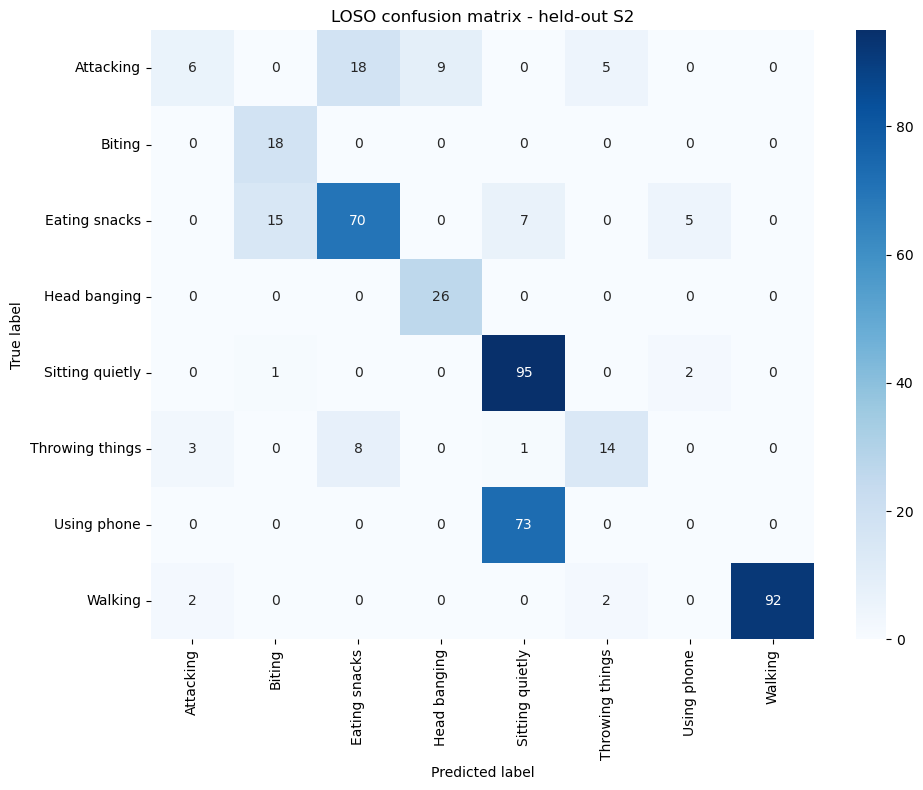

In [9]:
fold_s2 = run_loso_fold(subject_windows, held_out_subject=2, random_state=42)
fold_s2.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_2.csv')
show_loso_fold(fold_s2)

### LOSO S3: Held-Out Subject 3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,2853,703,0.375533,0.383077,0.493213,0.382456,0.694268


,precision,recall,f1-score,support
Attacking,0.240876,0.970588,0.385965,34.000000
Biting,0.200000,0.186441,0.192982,59.000000
Eating snacks,0.116279,0.142857,0.128205,70.000000
Head banging,0.469388,0.575000,0.516854,40.000000
Sitting quietly,0.777778,0.076503,0.139303,183.000000
Throwing things,0.431818,0.791667,0.558824,24.000000
Using phone,0.183673,0.225000,0.202247,160.000000
Walking,1.000000,0.887218,0.940239,133.000000
accuracy,0.375533,0.375533,0.375533,0.375533
macro avg,0.427477,0.481909,0.383077,703.000000


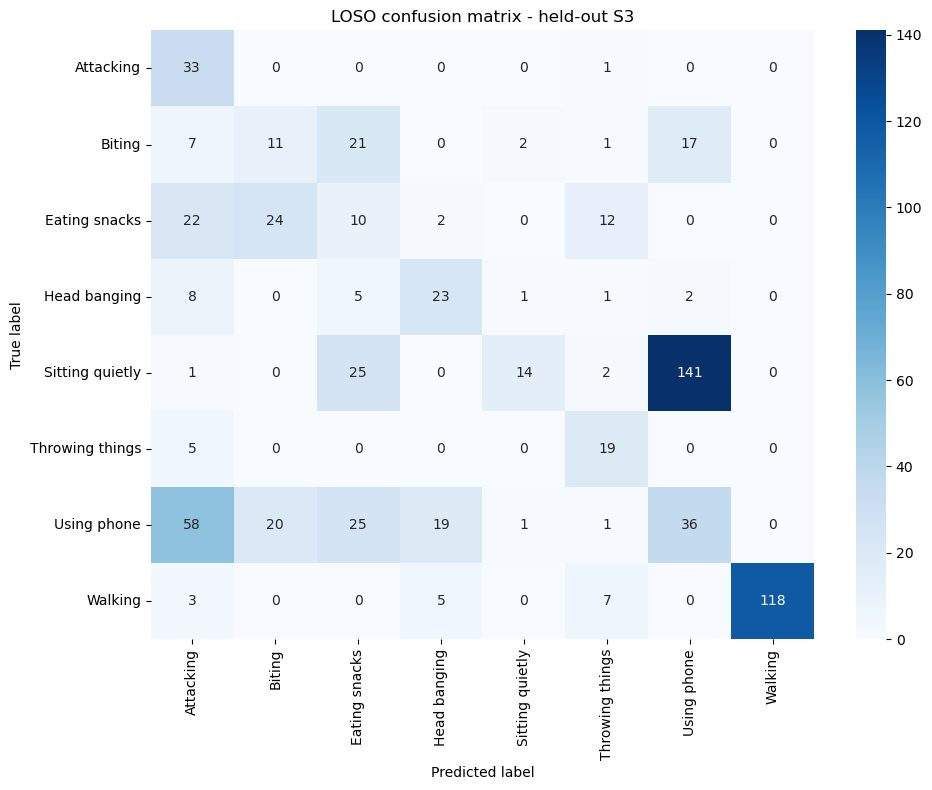

In [10]:
fold_s3 = run_loso_fold(subject_windows, held_out_subject=3, random_state=42)
fold_s3.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_3.csv')
show_loso_fold(fold_s3)

### LOSO S5: Held-Out Subject 5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,3317,471,0.783439,0.801505,0.995708,1.0,0.991453


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.000000
Biting,1.000000,0.973684,0.986667,38.000000
Eating snacks,0.866667,0.691489,0.769231,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.508108,0.959184,0.664311,98.000000
Throwing things,0.961538,1.000000,0.980392,25.000000
Using phone,1.000000,0.014706,0.028986,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.783439,0.783439,0.783439,0.783439
macro avg,0.917039,0.825573,0.801505,471.000000


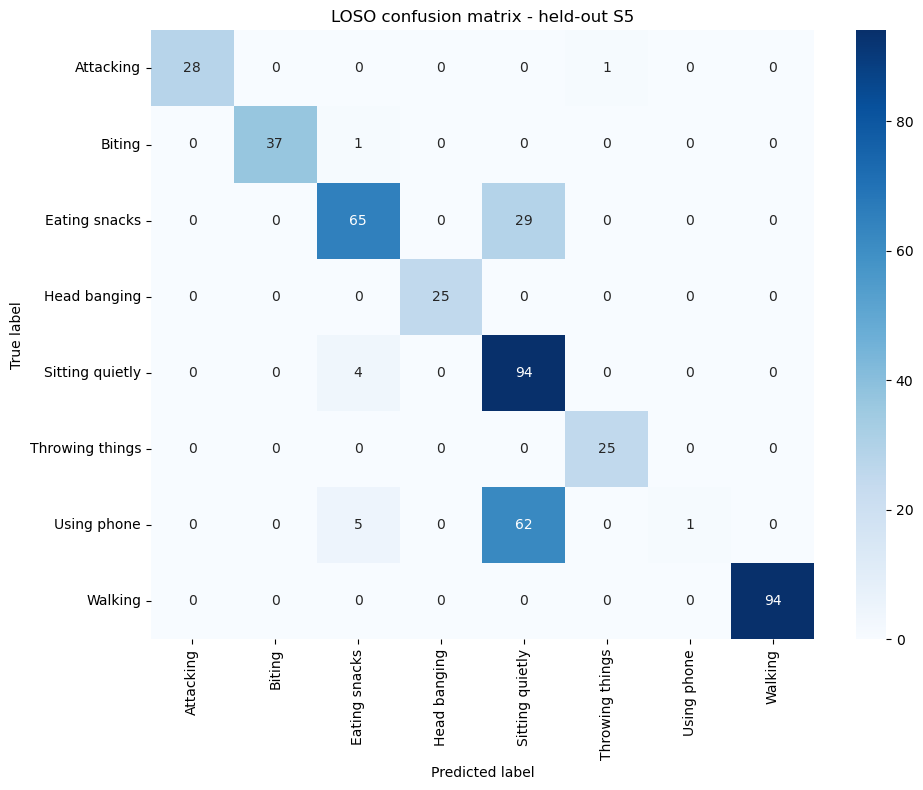

In [11]:
fold_s5 = run_loso_fold(subject_windows, held_out_subject=5, random_state=42)
fold_s5.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix_subject_5.csv')
show_loso_fold(fold_s5)

## 6. Combined LOSO Summary

In [12]:
loso = combine_loso_folds([fold_s1, fold_s2, fold_s3, fold_s5])
loso.fold_metrics.to_csv(ARTIFACT_DIR / 'loso_fold_metrics.csv', index=False)
loso.confusion.to_csv(ARTIFACT_DIR / 'loso_confusion_matrix.csv')
loso.classification_report.to_csv(ARTIFACT_DIR / 'loso_classification_report.csv')
(ARTIFACT_DIR / 'loso_summary.json').write_text(json.dumps(loso.summary, indent=2), encoding='utf-8')
display(loso.fold_metrics)
display(pd.Series(loso.summary, name='value').to_frame())

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,3299,482,0.551867,0.473515,0.582278,0.589744,0.575000
1,2,3317,472,0.680085,0.597869,0.775120,0.801980,0.750000
2,3,2853,703,0.375533,0.383077,0.493213,0.382456,0.694268
3,5,3317,471,0.783439,0.801505,0.995708,1.000000,0.991453


,value
mean_fold_accuracy,0.597731
std_fold_accuracy,0.152270
mean_fold_macro_f1,0.563992
mean_fold_abnormal_f1,0.711580
pooled_accuracy,0.573308
pooled_macro_f1,0.565513
pooled_abnormal_f1,0.669045


## 7. Final Training on S1, S2, S3, and S5 and Joblib Export

In [13]:
all_windows = concatenate_window_features([subject_windows[s] for s in SUBJECTS])
final_model = fit_estimator(all_windows)
artifact = build_artifact(final_model, all_windows.x.columns, metadata={
    'training_subjects': SUBJECTS,
    'training_files': {s: str(p.resolve()) for s, p in training_files.items()},
    'n_training_windows': len(all_windows.y),
    'class_window_counts': all_windows.y.value_counts().sort_index().to_dict(),
    'loso_summary': loso.summary,
})
MODEL_PATH = ARTIFACT_DIR / 'keypoint_tsfel_histgb_v7_compatible_1_2_3_5.joblib'
save_artifact(MODEL_PATH, artifact)
print(MODEL_PATH.resolve(), MODEL_PATH.stat().st_size, 'bytes')

.\artifacts\tsfel_histgb\keypoint_tsfel_histgb_v7_compatible_1_2_3_5.joblib 2660917 bytes


## 8. Artifact Reload Verification

In [14]:
artifact = load_artifact(MODEL_PATH)
assert artifact['metadata']['training_subjects'] == SUBJECTS
display(pd.Series({
    'architecture': artifact['architecture'],
    'features': len(artifact['feature_columns']),
    'training_windows': artifact['metadata']['n_training_windows'],
    'pooled_loso_accuracy': artifact['metadata']['loso_summary']['pooled_accuracy'],
}))

architecture            TSFEL+HistGradientBoosting
features                                      1891
training_windows                              4262
pooled_loso_accuracy                      0.573308
dtype: object

## 9. Shared-Test Prediction for S4

In [15]:
test_frame = pd.read_csv(TEST_FILE)
prediction = predict_frame_labels(test_frame, artifact, participant_id=PARTICIPANT_ID)
paths = write_prediction_outputs(OUTPUT_DIR, test_frame, prediction, PARTICIPANT_ID)
display(pd.Series(prediction.frame_labels).value_counts().rename('frames').to_frame())
print('Filled:', paths.filled.resolve())
print('Submission:', paths.submission.resolve())

,frames
Using phone,33000
Walking,20250
Sitting quietly,18300
Eating snacks,14121
Biting,13050
Head banging,6750
Throwing things,6300
Attacking,6150


Filled: .\outputs\tsfel_histgb\test_data_keypoint_shared_predicted.csv
Submission: .\outputs\tsfel_histgb\submission_tsfel_histgb.csv


In [16]:
filled = pd.read_csv(paths.filled)
submission = pd.read_csv(paths.submission)
assert len(filled) == len(submission) == len(test_frame)
assert submission.columns.tolist() == ['participant_id', 'timestamp', 'predicted_label']
assert not submission.predicted_label.isna().any()
display(filled.head())
display(submission.head())

,frame_id,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,...,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,predicted_label,prediction_confidence
0,0,630.5,420.50,638.5,413.00,621.5,413.50,649.5,419.25,610.0,...,702.0,581.5,567.0,595.5,618.0,602.0,654.0,608.0,Sitting quietly,0.991072
1,1,629.5,421.75,637.5,414.00,620.5,414.50,648.5,420.25,609.0,...,702.0,581.5,567.0,595.5,618.0,601.5,654.5,608.0,Sitting quietly,0.991072
2,2,629.0,423.25,637.0,415.50,620.0,416.00,648.0,421.00,608.0,...,702.0,581.0,567.0,595.0,616.5,601.0,654.5,608.5,Sitting quietly,0.991072
3,3,628.5,424.25,636.5,416.50,619.5,417.25,647.0,421.50,607.0,...,702.0,580.5,567.0,594.0,617.0,601.5,653.5,608.5,Sitting quietly,0.991072
4,4,628.5,425.75,636.0,417.75,619.0,418.75,646.0,422.50,606.5,...,702.0,580.0,567.0,593.0,616.5,601.5,651.5,609.5,Sitting quietly,0.991072


,participant_id,timestamp,predicted_label
0,4,0,Sitting quietly
1,4,1,Sitting quietly
2,4,2,Sitting quietly
3,4,3,Sitting quietly
4,4,4,Sitting quietly


## 10. Validate the Organizer-Provided S4 Ground Truth

In [17]:
s4_labeled = pd.read_csv(S4_LABEL_FILE)
validate_pose_columns(s4_labeled)
assert len(s4_labeled) == len(test_frame)
assert s4_labeled['frame_id'].equals(test_frame['frame_id'])
assert s4_labeled[['frame_id', *COORD_COLUMNS]].equals(test_frame[['frame_id', *COORD_COLUMNS]])
s4_labeled['Action Label'] = clean_labels(s4_labeled['Action Label'])
print('S4 ground truth matches the shared test exactly.')
display(s4_labeled['Action Label'].value_counts(dropna=False).rename('frames').to_frame())

S4 ground truth matches the shared test exactly.


,frames
Action Label,
Sitting quietly,24000
Using phone,23430
Walking,20190
Eating snacks,18810
None,9081
Biting,8490
Head banging,5880
Attacking,4350
Throwing things,3690


## 11. Evaluate the Stage-One Model on S4 Ground Truth

,value
accuracy,0.778666
macro_f1,0.810567
abnormal_f1,0.837182
abnormal_precision,0.750531
abnormal_recall,0.946452


,precision,recall,f1-score,support
Attacking,0.853659,0.965517,0.906149,4350.000000
Biting,0.599537,0.915194,0.724476,8490.000000
Eating snacks,0.851016,0.601276,0.704673,18810.000000
Head banging,0.989529,0.964286,0.976744,5880.000000
Sitting quietly,0.794118,0.573750,0.666183,24000.000000
Throwing things,0.735484,0.926829,0.820144,3690.000000
Using phone,0.640516,0.825864,0.721477,23430.000000
Walking,0.975684,0.953938,0.964688,20190.000000
accuracy,0.778666,0.778666,0.778666,0.778666
macro avg,0.804943,0.840832,0.810567,108840.000000


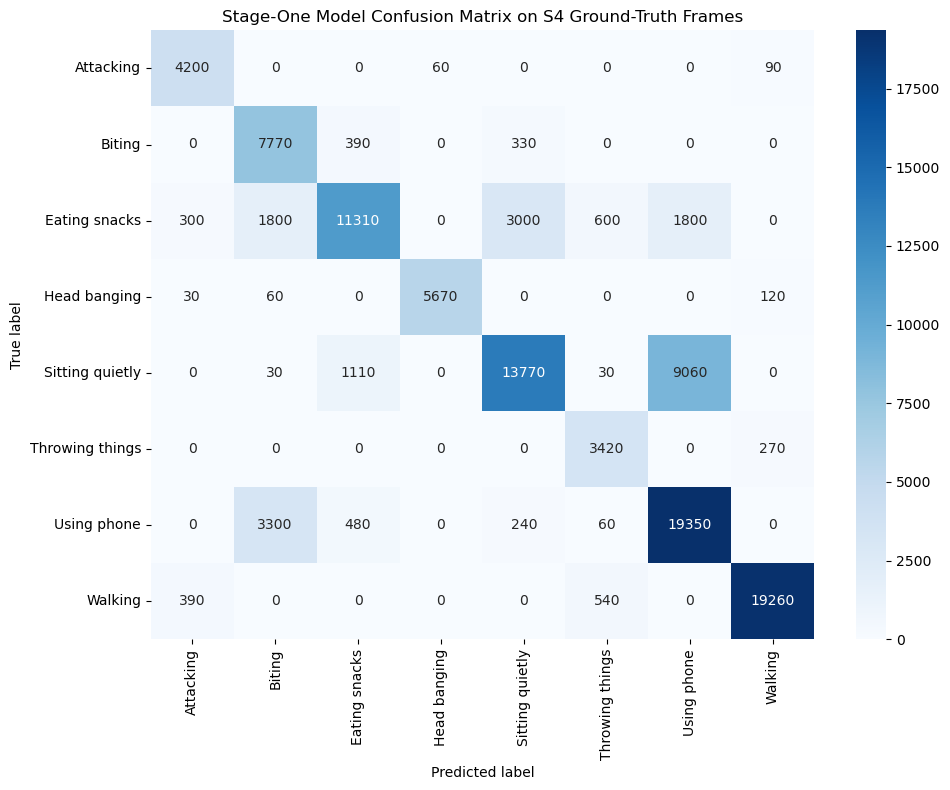

In [18]:
valid_s4_frames = s4_labeled['Action Label'].isin(CLASSES)
s4_frame_evaluation = evaluate_predictions(
    s4_labeled.loc[valid_s4_frames, 'Action Label'],
    prediction.frame_labels[valid_s4_frames.to_numpy()],
)
s4_frame_confusion = pd.DataFrame(
    confusion_matrix(
        s4_labeled.loc[valid_s4_frames, 'Action Label'],
        prediction.frame_labels[valid_s4_frames.to_numpy()],
        labels=CLASSES,
    ),
    index=CLASSES,
    columns=CLASSES,
)
s4_frame_metrics = {k: v for k, v in s4_frame_evaluation.items() if k != 'classification_report'}
(ARTIFACT_DIR / 's4_stage1_frame_metrics.json').write_text(json.dumps(s4_frame_metrics, indent=2), encoding='utf-8')
s4_frame_confusion.to_csv(ARTIFACT_DIR / 's4_stage1_frame_confusion_matrix.csv')
display(pd.Series(s4_frame_metrics, name='value').to_frame())
display(pd.DataFrame(s4_frame_evaluation['classification_report']).transpose())
plt.figure(figsize=(10, 8))
sns.heatmap(s4_frame_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Stage-One Model Confusion Matrix on S4 Ground-Truth Frames')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

Subject 4: reading data/keypointlabel/keypoints_with_labels_4.csv


Subject 4: extracting TSFEL from 117,921 frames


Subject 4: cached 1433 windows with 1891 features


,value
accuracy,0.783520
macro_f1,0.818874
abnormal_f1,0.841463
abnormal_precision,0.754098
abnormal_recall,0.951724


,precision,recall,f1-score,support
Attacking,0.870968,1.000000,0.931034,27.00000
Biting,0.604651,0.928571,0.732394,56.00000
Eating snacks,0.860465,0.596774,0.704762,124.00000
Head banging,1.000000,0.973684,0.986667,38.00000
Sitting quietly,0.800000,0.578616,0.671533,159.00000
Throwing things,0.758621,0.916667,0.830189,24.00000
Using phone,0.641791,0.832258,0.724719,155.00000
Walking,0.977099,0.962406,0.969697,133.00000
accuracy,0.783520,0.783520,0.783520,0.78352
macro avg,0.814199,0.848622,0.818874,716.00000


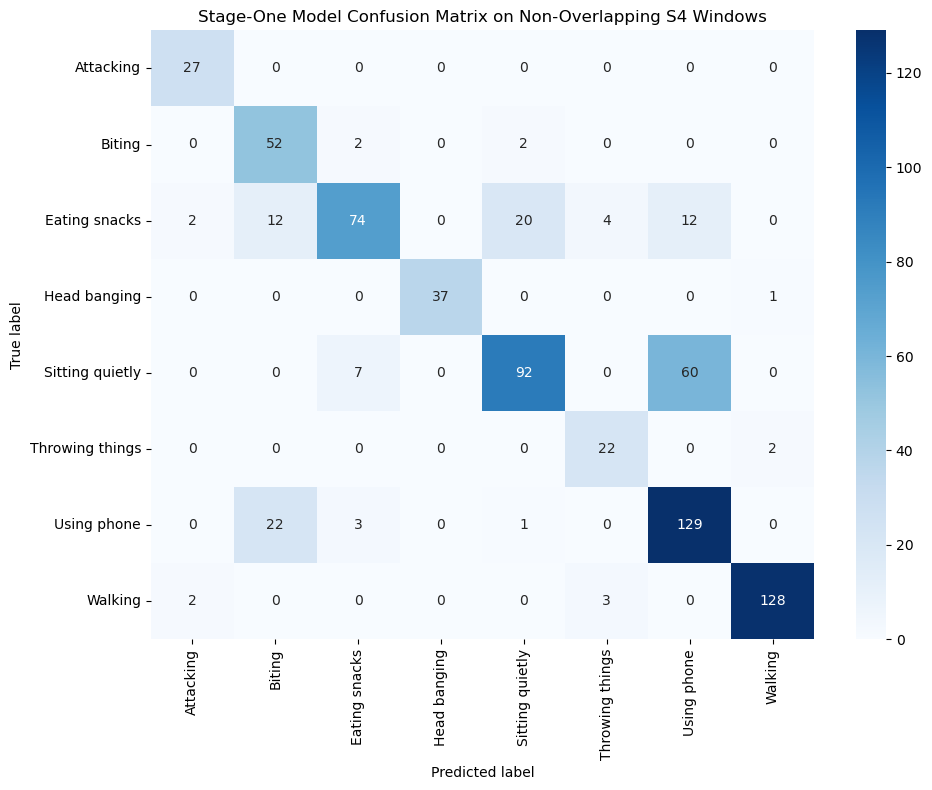

In [19]:
subject_windows[4] = load_or_extract_subject(
    S4_LABEL_FILE, 4, CACHE_DIR, config, force=False
)
s4_evaluation_windows = select_nonoverlapping_windows(subject_windows[4])
s4_window_predictions = artifact['model'].predict(s4_evaluation_windows.x)
s4_window_evaluation = evaluate_predictions(s4_evaluation_windows.y, s4_window_predictions)
s4_window_confusion = pd.DataFrame(
    confusion_matrix(s4_evaluation_windows.y, s4_window_predictions, labels=CLASSES),
    index=CLASSES,
    columns=CLASSES,
)
s4_window_metrics = {k: v for k, v in s4_window_evaluation.items() if k != 'classification_report'}
(ARTIFACT_DIR / 's4_stage1_window_metrics.json').write_text(json.dumps(s4_window_metrics, indent=2), encoding='utf-8')
s4_window_confusion.to_csv(ARTIFACT_DIR / 's4_stage1_window_confusion_matrix.csv')
display(pd.Series(s4_window_metrics, name='value').to_frame())
display(pd.DataFrame(s4_window_evaluation['classification_report']).transpose())
plt.figure(figsize=(10, 8))
sns.heatmap(s4_window_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Stage-One Model Confusion Matrix on Non-Overlapping S4 Windows')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## 12. Final Five-Subject LOSO

The five cells below retrain the model independently. Each fold trains on four subjects and evaluates the remaining held-out subject.

### Five-Subject LOSO: Held-Out S1

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,4732,482,0.516598,0.486602,0.628378,0.528409,0.775


,precision,recall,f1-score,support
Attacking,0.714286,0.517241,0.600000,29.000000
Biting,1.000000,0.472222,0.641509,36.000000
Eating snacks,0.450000,0.734694,0.558140,98.000000
Head banging,0.224299,0.960000,0.363636,25.000000
Sitting quietly,0.026316,0.010526,0.015038,95.000000
Throwing things,0.741935,0.766667,0.754098,30.000000
Using phone,0.000000,0.000000,0.000000,72.000000
Walking,0.923810,1.000000,0.960396,97.000000
accuracy,0.516598,0.516598,0.516598,0.516598
macro avg,0.510081,0.557669,0.486602,482.000000


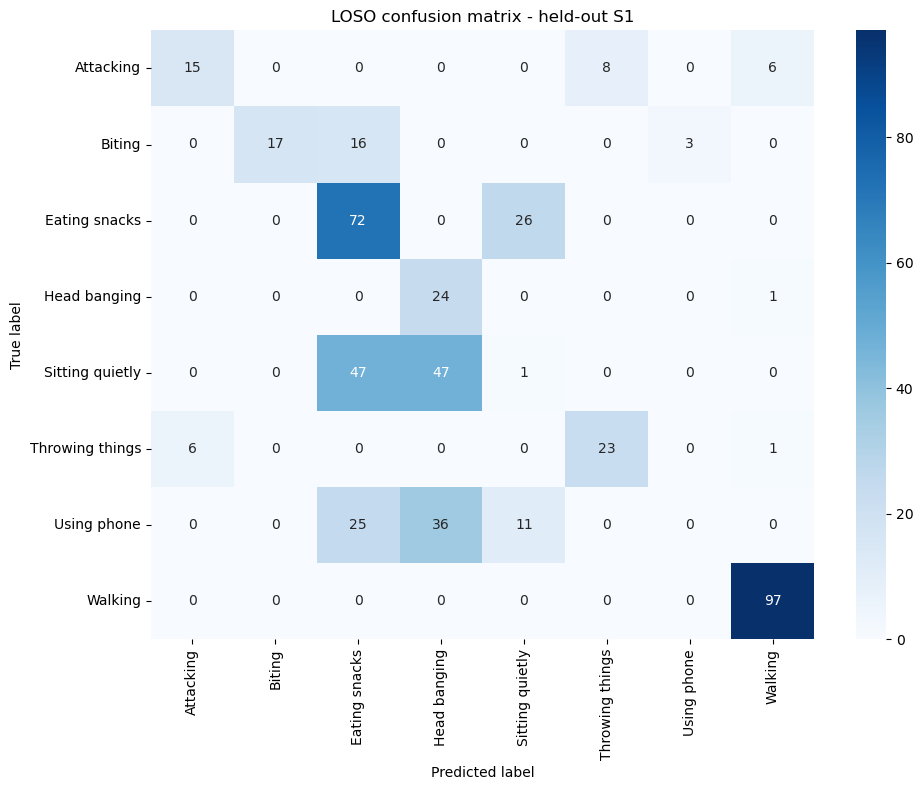

In [20]:
fold5_s1 = run_loso_fold(subject_windows, held_out_subject=1, random_state=84)
fold5_s1.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix_subject_1.csv')
show_loso_fold(fold5_s1)

### Five-Subject LOSO: Held-Out S2

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,2,4750,472,0.692797,0.581857,0.776699,0.816327,0.740741


,precision,recall,f1-score,support
Attacking,0.600000,0.078947,0.139535,38.000000
Biting,0.529412,1.000000,0.692308,18.000000
Eating snacks,0.728972,0.804124,0.764706,97.000000
Head banging,0.684211,1.000000,0.812500,26.000000
Sitting quietly,0.554913,0.979592,0.708487,98.000000
Throwing things,0.619048,0.500000,0.553191,26.000000
Using phone,0.000000,0.000000,0.000000,73.000000
Walking,1.000000,0.968750,0.984127,96.000000
accuracy,0.692797,0.692797,0.692797,0.692797
macro avg,0.589569,0.666427,0.581857,472.000000


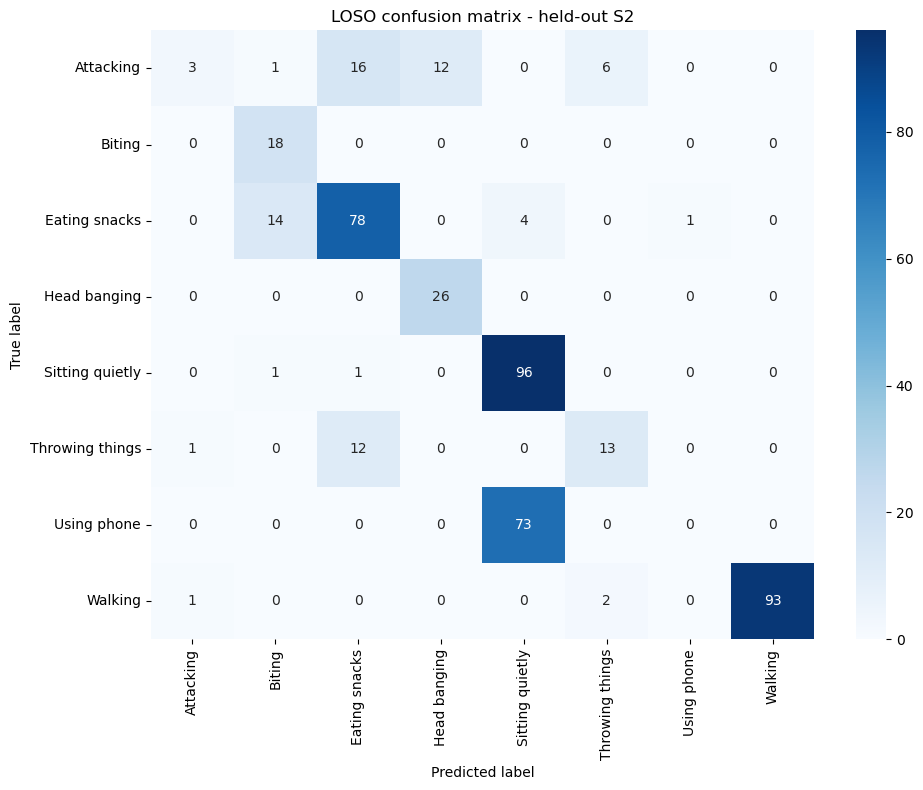

In [21]:
fold5_s2 = run_loso_fold(subject_windows, held_out_subject=2, random_state=84)
fold5_s2.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix_subject_2.csv')
show_loso_fold(fold5_s2)

### Five-Subject LOSO: Held-Out S3

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,3,4286,703,0.746799,0.739912,0.810036,0.92623,0.719745


,precision,recall,f1-score,support
Attacking,0.794872,0.911765,0.849315,34.000000
Biting,0.846154,0.372881,0.517647,59.000000
Eating snacks,0.478261,0.785714,0.594595,70.000000
Head banging,1.000000,0.725000,0.840580,40.000000
Sitting quietly,0.718232,0.710383,0.714286,183.000000
Throwing things,0.678571,0.791667,0.730769,24.000000
Using phone,0.721088,0.662500,0.690554,160.000000
Walking,0.963768,1.000000,0.981550,133.000000
accuracy,0.746799,0.746799,0.746799,0.746799
macro avg,0.775118,0.744989,0.739912,703.000000


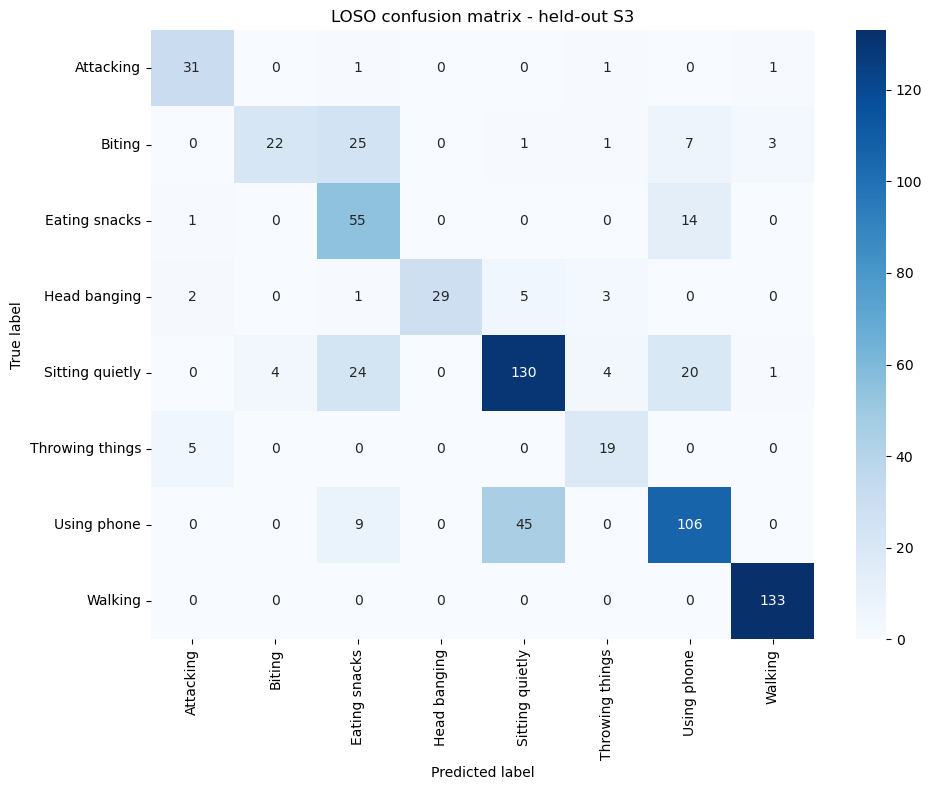

In [22]:
fold5_s3 = run_loso_fold(subject_windows, held_out_subject=3, random_state=84)
fold5_s3.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix_subject_3.csv')
show_loso_fold(fold5_s3)

### Five-Subject LOSO: Held-Out S4

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,4,4262,716,0.807263,0.834576,0.861538,0.777778,0.965517


,precision,recall,f1-score,support
Attacking,0.838710,0.962963,0.896552,27.000000
Biting,0.630952,0.946429,0.757143,56.000000
Eating snacks,0.846939,0.669355,0.747748,124.000000
Head banging,1.000000,0.973684,0.986667,38.000000
Sitting quietly,0.859649,0.616352,0.717949,159.000000
Throwing things,0.785714,0.916667,0.846154,24.000000
Using phone,0.673575,0.838710,0.747126,155.000000
Walking,0.984733,0.969925,0.977273,133.000000
accuracy,0.807263,0.807263,0.807263,0.807263
macro avg,0.827534,0.861760,0.834576,716.000000


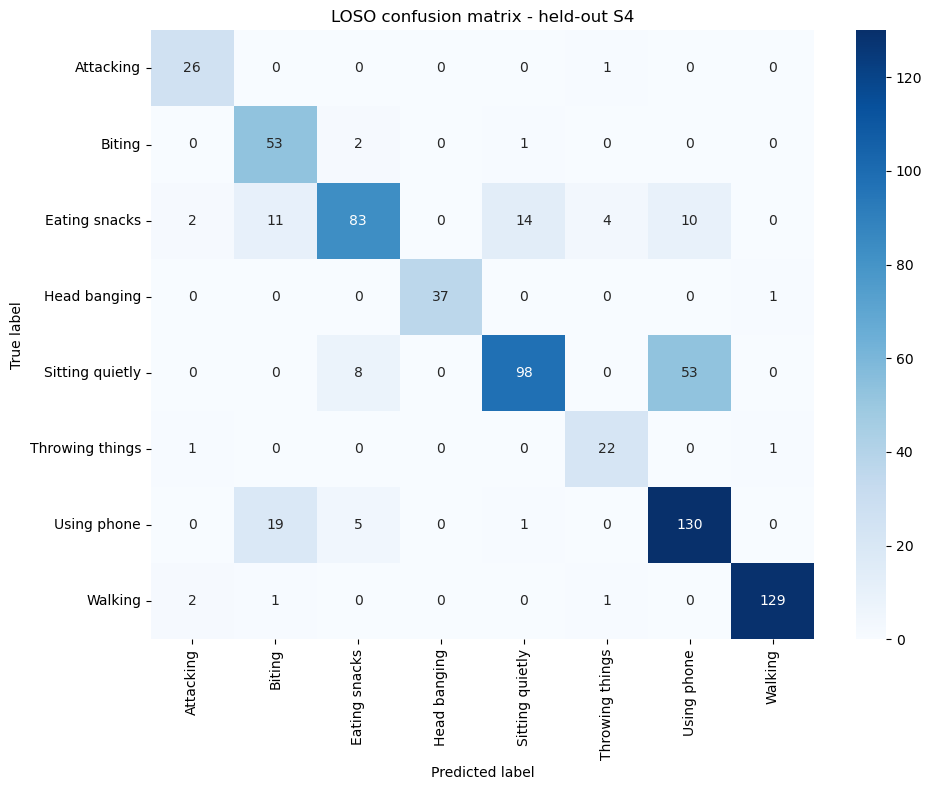

In [23]:
fold5_s4 = run_loso_fold(subject_windows, held_out_subject=4, random_state=84)
fold5_s4.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix_subject_4.csv')
show_loso_fold(fold5_s4)

### Five-Subject LOSO: Held-Out S5

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,5,4750,471,0.798301,0.82915,0.995708,1.0,0.991453


,precision,recall,f1-score,support
Attacking,1.000000,0.965517,0.982456,29.000000
Biting,1.000000,0.973684,0.986667,38.000000
Eating snacks,0.730000,0.776596,0.752577,94.000000
Head banging,1.000000,1.000000,1.000000,25.000000
Sitting quietly,0.556291,0.857143,0.674699,98.000000
Throwing things,0.961538,1.000000,0.980392,25.000000
Using phone,1.000000,0.147059,0.256410,68.000000
Walking,1.000000,1.000000,1.000000,94.000000
accuracy,0.798301,0.798301,0.798301,0.798301
macro avg,0.905979,0.840000,0.829150,471.000000


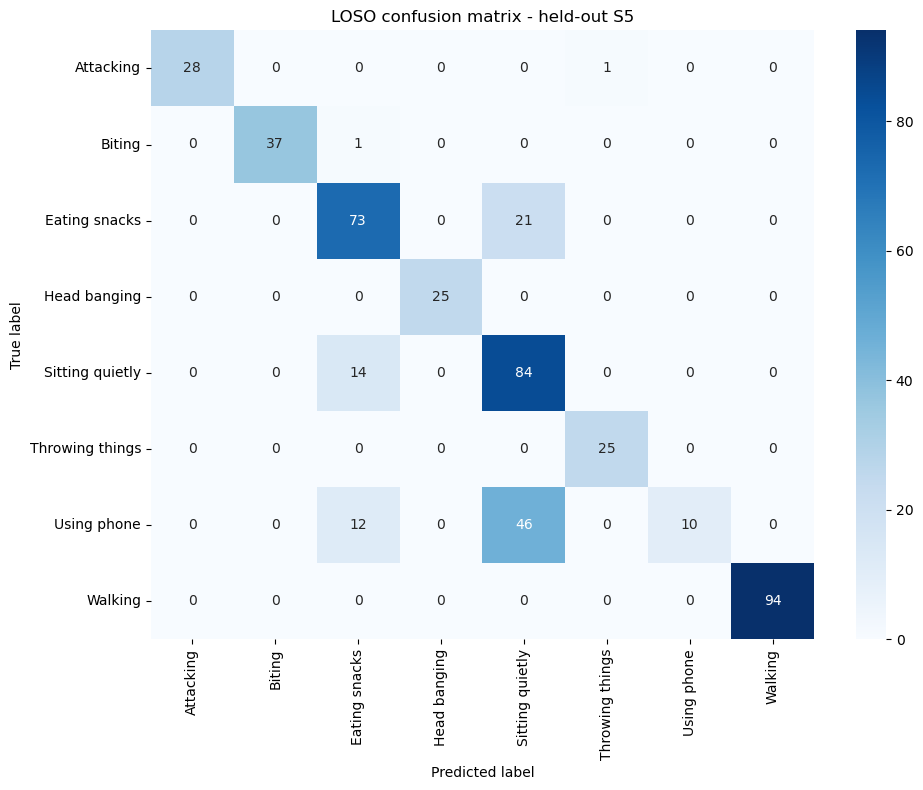

In [24]:
fold5_s5 = run_loso_fold(subject_windows, held_out_subject=5, random_state=84)
fold5_s5.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix_subject_5.csv')
show_loso_fold(fold5_s5)

## 13. Combined Five-Subject LOSO Results

In [25]:
loso5 = combine_loso_folds([fold5_s1, fold5_s2, fold5_s3, fold5_s4, fold5_s5])
loso5.fold_metrics.to_csv(ARTIFACT_DIR / 'loso5_fold_metrics.csv', index=False)
loso5.confusion.to_csv(ARTIFACT_DIR / 'loso5_confusion_matrix.csv')
loso5.classification_report.to_csv(ARTIFACT_DIR / 'loso5_classification_report.csv')
(ARTIFACT_DIR / 'loso5_summary.json').write_text(json.dumps(loso5.summary, indent=2), encoding='utf-8')
display(loso5.fold_metrics)
display(pd.Series(loso5.summary, name='value').to_frame())

,held_out_subject,n_train_windows,n_test_windows,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,4732,482,0.516598,0.486602,0.628378,0.528409,0.775000
1,2,4750,472,0.692797,0.581857,0.776699,0.816327,0.740741
2,3,4286,703,0.746799,0.739912,0.810036,0.926230,0.719745
3,4,4262,716,0.807263,0.834576,0.861538,0.777778,0.965517
4,5,4750,471,0.798301,0.829150,0.995708,1.000000,0.991453


,value
mean_fold_accuracy,0.712352
std_fold_accuracy,0.106098
mean_fold_macro_f1,0.694419
mean_fold_abnormal_f1,0.814472
pooled_accuracy,0.722574
pooled_macro_f1,0.726145
pooled_abnormal_f1,0.809559


## 14. Final Model Trained on All Five Labeled Subjects

In [26]:
all_five_windows = concatenate_window_features([subject_windows[s] for s in [1, 2, 3, 4, 5]])
final_model_5 = fit_estimator(all_five_windows, random_state=84)
artifact_5 = build_artifact(final_model_5, all_five_windows.x.columns, metadata={
    'training_subjects': [1, 2, 3, 4, 5],
    'training_files': {
        **{s: str(p.resolve()) for s, p in training_files.items()},
        4: str(S4_LABEL_FILE.resolve()),
    },
    'n_training_windows': len(all_five_windows.y),
    'class_window_counts': all_five_windows.y.value_counts().sort_index().to_dict(),
    'loso_summary': loso5.summary,
})
MODEL_PATH_5 = ARTIFACT_DIR / 'keypoint_tsfel_histgb_v7_compatible_1_2_3_4_5.joblib'
save_artifact(MODEL_PATH_5, artifact_5)
artifact_5 = load_artifact(MODEL_PATH_5)
display(pd.Series({
    'model_path': str(MODEL_PATH_5.resolve()),
    'artifact_bytes': MODEL_PATH_5.stat().st_size,
    'features': len(artifact_5['feature_columns']),
    'training_windows': artifact_5['metadata']['n_training_windows'],
    'pooled_loso_accuracy': artifact_5['metadata']['loso_summary']['pooled_accuracy'],
    'pooled_loso_macro_f1': artifact_5['metadata']['loso_summary']['pooled_macro_f1'],
    'pooled_loso_abnormal_f1': artifact_5['metadata']['loso_summary']['pooled_abnormal_f1'],
}))

model_path                 .\artifact...
artifact_bytes                                                       2889951
features                                                                1891
training_windows                                                        5695
pooled_loso_accuracy                                                0.722574
pooled_loso_macro_f1                                                0.726145
pooled_loso_abnormal_f1                                             0.809559
dtype: object

## 15. Predicting Another Unseen Dataset

Use the four-subject artifact for a genuinely unseen participant. Use the five-subject artifact only after S4 ground truth has been released.

Run `predict_tsfel_histgb.py --model artifacts/tsfel_histgb/keypoint_tsfel_histgb_v7_compatible_1_2_3_4_5.joblib --input <file.csv> --participant-id <id>`.